## TKerki top 10 particles CMIP run

### ToDo
- automate in .py?
- fix links to forcing and shapefiles etc
- auto delete files

In [1]:
# General python
import warnings

warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path

# General eWaterCycle
import ewatercycle
import ewatercycle.forcing
import ewatercycle.models

# fiona
import fiona
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shapely.geometry
import xarray as xr
from pyproj import Geod

# Niceties
from rich import print

# progressbar
from tqdm.notebook import tqdm

# timezone

In [2]:
# The name of the shapefile
shape_file_name = "Kerki_GRDC"  # river: Bedford Ouse at Roxton, England

# The time-window of the experiment
experiment_start_date = "2060-01-01T00:00:00Z"
experiment_end_date = "2070-12-31T00:00:00Z"


datetime_end = pd.to_datetime(experiment_end_date)
datetime_end_naive = datetime_end.tz_localize(None)

forcing_path_CMIP = (
    Path.cwd()
    / ".."
    / ".."
    / ".."
    / "forcing"
    / "output"
    / "CMIP"
    / f"forcing_HBV_{shape_file_name}"
    / "CMIP6"
    / "future"
    / "Lumped"
)


load_location = forcing_path_CMIP / "work" / "diagnostic" / "script"
CMIP_forcing = ewatercycle.forcing.sources["LumpedMakkinkForcing"].load(directory=load_location)

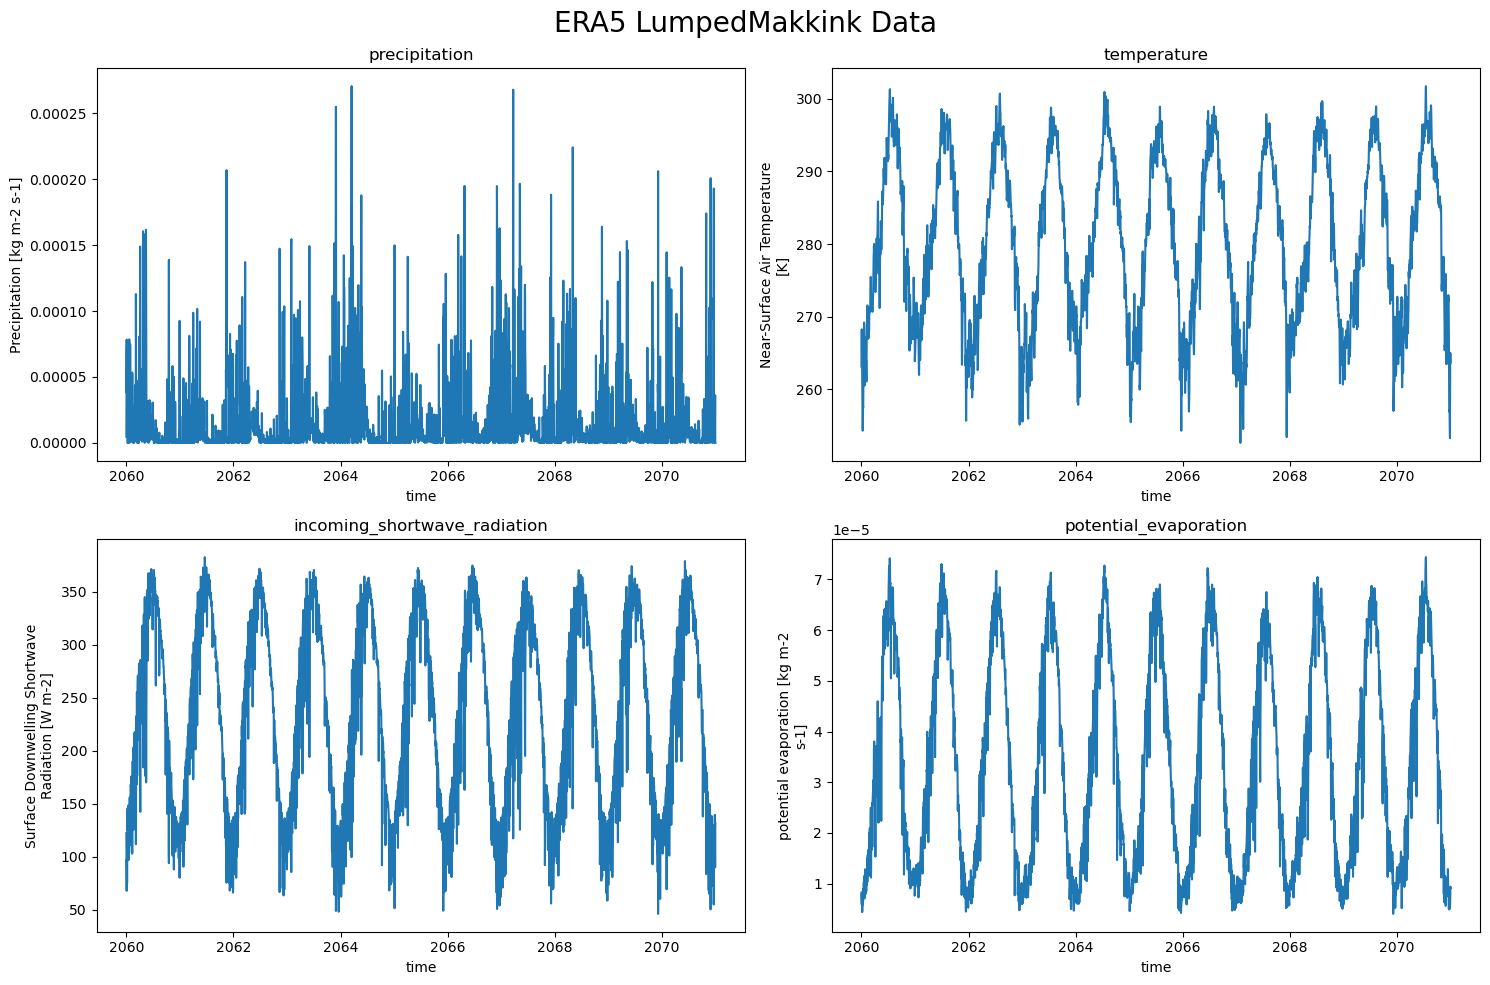

In [3]:
CMIP_data = {
    "precipitation pr": xr.open_dataset(CMIP_forcing["pr"]),
    "temperature tas": xr.open_dataset(CMIP_forcing["tas"]),
    "incoming_shortwave_radiation rsds": xr.open_dataset(CMIP_forcing["rsds"]),
    "potential_evaporation evspsblpot": xr.open_dataset(CMIP_forcing["evspsblpot"]),
}

plot_counter = 1
plt.figure(figsize=(15, 10))
for name, data in CMIP_data.items():
    plt.subplot(2, 2, plot_counter)
    data[name.split(" ")[-1]].plot()
    plt.title(f"{name.split(" ")[0]}")
    plot_counter += 1

plt.suptitle("ERA5 LumpedMakkink Data", fontsize=20)
plt.tight_layout()

In [4]:
from ewatercycle.observation.grdc import get_grdc_data

ds = get_grdc_data(
    2617110,
    "1900-01-01T00:00Z",
    "2000-12-31T00:00Z",
    data_home="/home/avandervee3/MSc_AralSea/book/thesis_projects/MSc/2025_Q1_AndreVanDerVeen_CEG/work_in_progress/Test_Aral/",
)
print(f"station = {ds.station_name.values}")

station = KERKI

In [5]:
hbv_dir = Path("../ensemble_5060")


file_param_metrics = hbv_dir / "HBV_Kerki_ensemble_5059_params.nc"


hbv_params_metrics = xr.open_dataset(file_param_metrics, engine="netcdf4")


hbv_params_metrics.close()

In [6]:
# print(hbv_params["hbv_parameters"].sel(particle = 10).values)

particles = [70, 57, 187, 44, 133, 246, 218, 70, 211, 138]
da_sel = hbv_params_metrics["hbv_parameters"].sel(particle=particles)
param_array_metrics = da_sel.to_numpy()
param_array_metrics

array([[1.83173533e+01, 4.81126981e-01, 1.08549177e+02, 6.40100506e-01,
        1.98226559e-01, 1.26430689e+01, 1.24203260e-02, 5.24067564e-03,
        3.48445648e-01],
       [1.27339596e+01, 9.54632086e-01, 3.68008336e+02, 7.99435546e-01,
        5.23350711e-02, 1.31420477e+00, 1.58872570e-02, 4.12147673e-03,
        2.96910609e-01],
       [9.07745448e+00, 4.93388369e-01, 8.60506709e+01, 5.45491431e-01,
        2.34131161e-01, 5.35270998e+00, 1.52676038e-02, 6.49651328e-03,
        2.92399075e-01],
       [1.43663229e+01, 7.10954587e-01, 5.86564422e+02, 5.04837922e-01,
        1.01448020e-01, 1.02735531e+01, 1.58349034e-02, 1.73427534e-03,
        2.77763206e-01],
       [1.25970293e+01, 5.47974974e-01, 4.97499785e+02, 5.41909823e-01,
        1.44003385e-01, 7.07018692e+00, 1.21388370e-02, 1.57669207e-03,
        4.50341606e-01],
       [1.61747031e+01, 9.77887611e-01, 7.83062043e+02, 8.33251903e-01,
        2.78254304e-01, 3.48677978e+00, 1.48984438e-02, 3.29450086e-03,
        1.7

In [7]:
n_particles = len(param_array_metrics)

In [8]:
## Array of initial storage terms - we keep these constant for now
##              Si,  Su, Sf, Ss
s_0 = np.array([0, 100, 0, 5, 0])

## Array of parameters min/max bounds as a reference
# ##                      Imax,  Ce,  Sumax, beta,  Pmax,  T_lag,   Kf,   Ks,    Fm
# parameter_set_fromsomewhere =  [
#     7.085,  # Imax
#     0.837,  # Ce
#     76.373, # Sumax
#     1.112,  # Beta
#     0.245,  # Pmax
#     7.801,  # Tlag
#     0.096,  # Kf
#     0.003,  # Ks
#     0.226   # FM
# ]


# param_array = np.array(parameter_set_fromsomewhere)
# # p_min_initial = np.array(parameter_set_fromsomewhere) * [0.5, 0.5, 0.5, 0.5, 0.5, 0.5, 0.1, 0.1, 0.5]
# # p_max_initial = np.array(parameter_set_fromsomewhere) * [1.5, 2.5, 1.5, 1.5, 1.5, 5, 2, 2, 1.5]
# ##                      Imax,  Ce,   Sumax,  beta,   Pmax,   T_lag,    Kf,    Ks,     Fm
# #p_min_initial=  0.3 * param_array #np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
# #p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
# p_min_initial = np.array([0,   0.2,  40,    .5,   .001,   1,     .01,  .0001,   0.01])
# p_max_initial =np.array([25,    1,  800,   4,    .3,     15,    .02,   .01,      0.8])
# #p_max_initial =np.array([25,    1,  800,   4,    .3,     80,    .1,   .01,      1])
# #p_max_initial = 10 * param_array #np.array(10*parameter_set_fromsomewhere) # np.array([25,    1,  800,   4,    .3,     100,    .1,   .01,      1])
# array_random_num = np.array([[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)])
# p_initial = p_min_initial + array_random_num * (p_max_initial-p_min_initial)


# p_names = ["$I_{max}$",  "$C_e$",  "$Su_{max}$", "β",  "$P_{max}$",  "$T_{lag}$",   "$K_f$",   "$K_s$"]
# S_names = ["Interception storage", "Unsaturated Rootzone Storage", "Fastflow storage", "Groundwater storage"]
param_names = ["Imax", "Ce", "Sumax", "Beta", "Pmax", "Tlag", "Kf", "Ks", "Fm"]
# stor_names = ["Si", "Su", "Sf", "Ss", "Sp"]

# set initial as mean of max,min
# par_0 = (p_min_initial + p_max_initial)/2

In [9]:
# array_random_num = np.array([[np.random.random() for i in range(len(p_max_initial))] for i in range(n_particles)])
# p_initial = p_min_initial + array_random_num * (p_max_initial-p_min_initial)

In [9]:
all_discharges = []
all_param_values = []


for i in tqdm(range(n_particles), desc="Running HBV experiments"):
    # params = dict(zip(param_names, p_initial[i]))
    params_array = param_array_metrics[i]

    model = ewatercycle.models.HBV(forcing=CMIP_forcing)

    cfg_file, _ = model.setup(parameters=params_array, initial_storage=s_0)
    model.initialize(cfg_file)

    Q_m = []
    time = []

    while model.time_as_datetime < datetime_end_naive:
        model.update()
        Q_m.append(model.get_value("Q")[0])  # punt-HBV, 1-element array
        time.append(pd.Timestamp(model.time_as_datetime))

    model.finalize()

    # Q per timestep
    discharge_da = xr.DataArray(Q_m, coords={"time": time}, dims=["time"])
    discharge_da = discharge_da.expand_dims("particle").assign_coords(particle=[i])
    all_discharges.append(discharge_da)

    # parameters as DataArray
    param_da = xr.DataArray(
        param_array_metrics[i], coords={"parameter": param_names}, dims=["parameter"]
    )
    param_da = param_da.expand_dims("particle").assign_coords(particle=[i])
    all_param_values.append(param_da)

# combine data arrays
discharge_ensemble = xr.concat(all_discharges, dim="particle")
param_array = xr.concat(all_param_values, dim="particle")

Running HBV experiments:   0%|          | 0/10 [00:00<?, ?it/s]

In [10]:
discharge_da

<xarray.DataArray (particle: 1, time: 4017)> Size: 32kB
array([[0.00041892, 0.00167856, 0.00378462, ..., 0.11639878, 0.1150578 ,
        0.11373544]])
Coordinates:
  * time      (time) datetime64[ns] 32kB 2060-01-02T12:00:00 ... 2070-12-31T1...
  * particle  (particle) int64 8B 9

In [11]:
discharge_ensemble

<xarray.DataArray (particle: 10, time: 4017)> Size: 321kB
array([[0.00032127, 0.00129442, 0.00293794, ..., 0.25035232, 0.24773932,
        0.24515968],
       [0.02066588, 0.02063909, 0.02061232, ..., 0.16889845, 0.16637398,
        0.16388957],
       [0.00273763, 0.01106943, 0.02386161, ..., 0.31071203, 0.30668651,
        0.30271794],
       ...,
       [0.00032127, 0.00129442, 0.00293794, ..., 0.25035232, 0.24773932,
        0.24515968],
       [0.00155979, 0.00623823, 0.01403347, ..., 0.16595073, 0.16334009,
        0.16078022],
       [0.00041892, 0.00167856, 0.00378462, ..., 0.11639878, 0.1150578 ,
        0.11373544]])
Coordinates:
  * time      (time) datetime64[ns] 32kB 2060-01-02T12:00:00 ... 2070-12-31T1...
  * particle  (particle) int64 80B 0 1 2 3 4 5 6 7 8 9

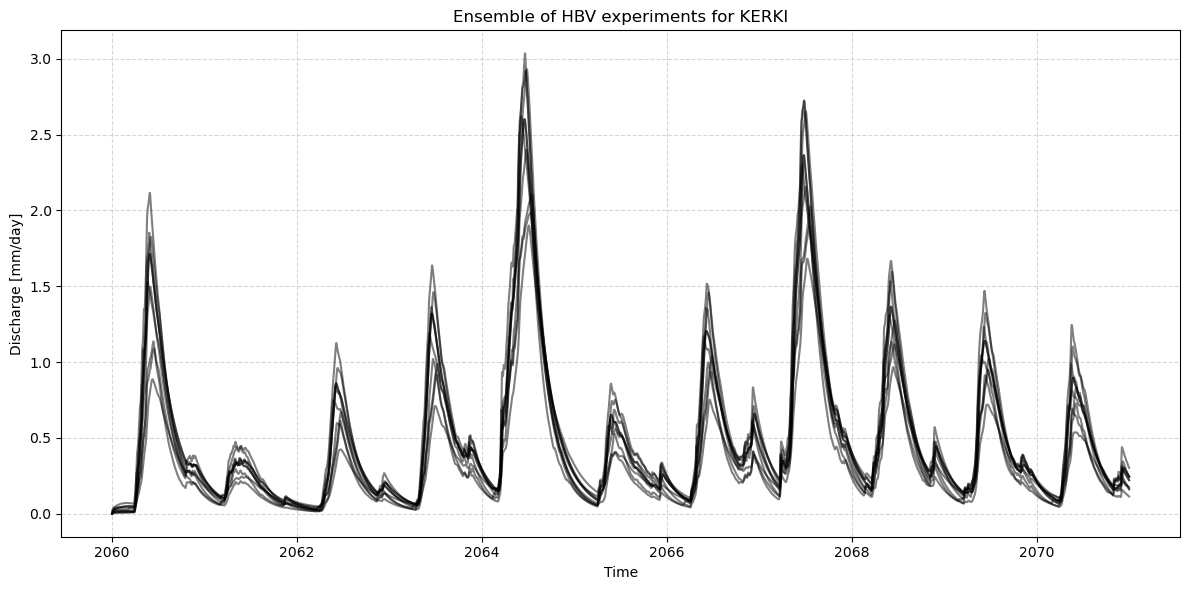

In [12]:
discharge_1955 = discharge_ensemble.sel(time=slice("2060-01-01", "2070-12-31"))


plt.figure(figsize=(12, 6))

for i, leak in enumerate(discharge_1955.particle.values):
    plt.plot(
        discharge_1955.time,
        discharge_1955.isel(particle=i),
        label=f"leakiness={leak:.2f}",
        color="black",
        alpha=0.5,
    )

plt.xlabel("Time")
plt.ylabel("Discharge [mm/day]")
plt.title(f"Ensemble of HBV experiments for {ds.station_name.values}")
# plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [13]:
def catchment_area_from_shapefile(shapefile_path, ellps="WGS84"):
    """
    Compute the area (in m²) of the first polygon in a shapefile.

    Parameters
    ----------
    shapefile_path : str
        Path to the shapefile (.shp)
    ellps : str, optional
        Ellipsoid for area calculation (default: WGS84)

    Returns
    -------
    float
        Absolute area of the polygon in square meters
    """
    # Load polygon
    with fiona.open(shapefile_path) as src:
        poly = shapely.geometry.shape(src[0]["geometry"])

    # Define ellipsoid
    geod = Geod(ellps=ellps)

    # Compute area and perimeter
    area, _ = geod.geometry_area_perimeter(poly)

    return abs(area)

In [14]:
shapefile_path = (
    Path.cwd()
    / ".."
    / ".."
    / ".."
    / "data"
    / "shapefiles"
    / shape_file_name
    / f"{shape_file_name}.shp"
).resolve()


area_station = catchment_area_from_shapefile(shapefile_path)
conversion_mmday2m3s = 1 / (1000 * 86400)

conversion_factor = conversion_mmday2m3s * area_station

In [15]:
discharge_m3s = discharge_ensemble * conversion_factor

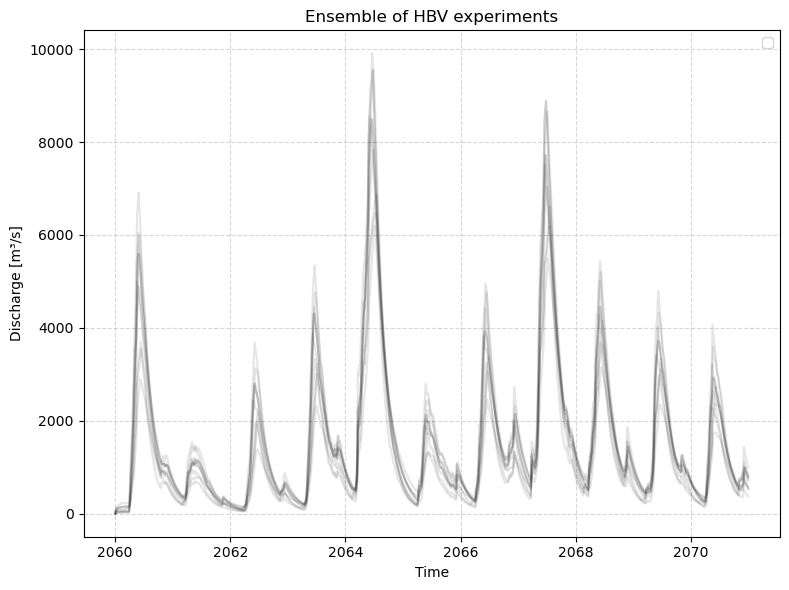

In [17]:
discharge_1955_m3 = discharge_m3s.sel(time=slice("2060-01-01", "2070-12-31"))
# ds_slice = ds.sel(time=slice("1959-01-01", "1959-12-31"))


plt.figure(figsize=(8, 6))

for i, leak in enumerate(discharge_1955_m3.particle.values):
    plt.plot(
        discharge_1955_m3.time,
        discharge_1955_m3.isel(particle=i),
        # label=f"particle {leak}",
        color="black",
        alpha=0.1,
    )


# ds_slice['streamflow'].plot(label = 'GRDC observations')

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of HBV experiments")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.ylim(0,max_y)
plt.show()

In [18]:
discharge_ensemble.name = "discharge"
discharge_ensemble.attrs["units"] = "mm/day"
discharge_ensemble.to_netcdf("HBV_Kerki_ensemble_CMIP_future_mmd.nc")

discharge_m3s.name = "discharge"
discharge_m3s.attrs["units"] = "m3/s"
discharge_m3s.to_netcdf("HBV_Kerki_ensemble_CMIP_future_m3s.nc")

param_array.name = "hbv_parameters"
param_array.attrs["description"] = "HBV parameter values per ensemble member"
param_array.to_netcdf("HBV_Kerki_ensemble_CMIP_future_params.nc")

In [19]:
discharge_ensemble

<xarray.DataArray 'discharge' (particle: 10, time: 4017)> Size: 321kB
array([[0.00032127, 0.00129442, 0.00293794, ..., 0.25035232, 0.24773932,
        0.24515968],
       [0.02066588, 0.02063909, 0.02061232, ..., 0.16889845, 0.16637398,
        0.16388957],
       [0.00273763, 0.01106943, 0.02386161, ..., 0.31071203, 0.30668651,
        0.30271794],
       ...,
       [0.00032127, 0.00129442, 0.00293794, ..., 0.25035232, 0.24773932,
        0.24515968],
       [0.00155979, 0.00623823, 0.01403347, ..., 0.16595073, 0.16334009,
        0.16078022],
       [0.00041892, 0.00167856, 0.00378462, ..., 0.11639878, 0.1150578 ,
        0.11373544]])
Coordinates:
  * time      (time) datetime64[ns] 32kB 2060-01-02T12:00:00 ... 2070-12-31T1...
  * particle  (particle) int64 80B 0 1 2 3 4 5 6 7 8 9
Attributes:
    units:    mm/day

In [20]:
# max per particle
max_per_particle = discharge_1955_m3.max(dim="time")  # DataArray met dim particle

# particle with highest max value
particle_idx = max_per_particle.argmax().item()  # returns index

# highest value
highest_discharge = max_per_particle.max().item()

print(f"Particle {particle_idx} has the highest max discharge: {highest_discharge}")

Particle 1 has the highest max discharge: 9910.031550339569

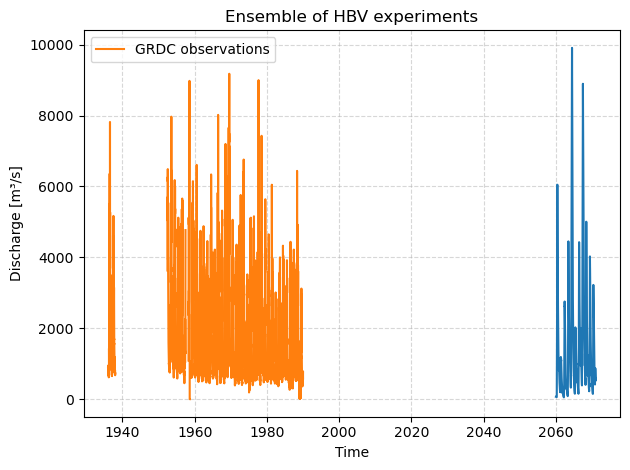

In [21]:
plt.plot(
    discharge_1955_m3.time,
    discharge_1955_m3.isel(particle=particle_idx),
)


# plot GRDC
max_y = 2 * ds["streamflow"].max()
ds["streamflow"].plot(label="GRDC observations")

plt.xlabel("Time")
plt.ylabel("Discharge [m³/s]")
plt.title("Ensemble of HBV experiments")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
# plt.ylim(0,max_y)
plt.show()

In [29]:
import hydrostats as hs
import hydrostats.analyze as ha
import pandas as pd
from hydrostats.metrics import dr, kge_2009, kge_2012, nse, nse_mod, nse_rel

df = pd.DataFrame(
    {
        "obs": ds["streamflow"].values[:1095],
        "sim": discharge_1955_m3.isel(particle=particle_idx).values[:1095],
    },
    index=ds["streamflow"].time[:1095],
)

# merge_data kan dan gebruikt worden met DataFrames
merged_df = hs.data.merge_data(sim_df=df["sim"], obs_df=df["obs"], column_names=("sim", "obs"))

ValueError: Length of values (365) does not match length of index (1095)

In [ ]:
merged_df

In [ ]:
# maak de time-lag plot
_ = ha.time_lag(
    merged_df,
    shift_range=(-90, 90),
    metrics=[nse.abbr, kge_2012.abbr, dr.abbr, kge_2009.abbr, nse_rel.abbr, nse_mod.abbr],
    plot=True,
)

In [ ]:
time_lag_df, summary_df = ha.time_lag(
    merged_df,
    shift_range=(-90, 90),
    metrics=[nse.abbr, nse_rel.abbr, nse_mod.abbr, kge_2009.abbr, kge_2012.abbr, dr.abbr],
)

In [ ]:
time_lag_df.plot()
plt.grid(linestyle="--", alpha=0.5)
plt.title("Metric values between as different time lags")
plt.ylabel("Metric Value [-]")
plt.xlabel("Time lag [days]")